In [ ]:
import os
import pandas as pd

files = os.listdir('.')
print("Current dir files:", files)

excel_file_name = 'Adidas US Sales Datasets.xlsx'
actual_file_path = None

# Search for the Excel file across the entire filesystem
for root, dirs, f_list in os.walk('/'):
    if excel_file_name in f_list:
        actual_file_path = os.path.join(root, excel_file_name)
        break

if actual_file_path:
    print(f"Loading data from Excel file: {actual_file_path}")
    xls = pd.ExcelFile(actual_file_path)
    print("Sheet names:", xls.sheet_names)
    # Assuming the first sheet and header is on the 4th row (index 3)
    df_preview = pd.read_excel(xls, sheet_name=xls.sheet_names[0], header=3)
    print(df_preview.head(10))
    print(df_preview.info())
else:
    # If the Excel file is not found, check if 'adidas.csv' exists in the current directory
    if 'adidas.csv' in files:
        csv_file_path = 'adidas.csv'
        print(f"'{excel_file_name}' not found. Loading '{csv_file_path}' instead.")
        # Assuming the header is on the 4th row (index 3)
        df_preview = pd.read_csv(csv_file_path, header=3)
        print(df_preview.head(10))
        print(df_preview.info())
    else:
        # If neither is found, raise a clear error
        raise FileNotFoundError(f"Neither '{excel_file_name}' nor 'adidas.csv' could be found.")

Current dir files: ['.config', 'adidas.csv', 'sample_data']
'Adidas US Sales Datasets.xlsx' not found. Loading 'adidas.csv' instead.
   Unnamed: 0   Unnamed: 1             Unnamed: 2    Unnamed: 3 Unnamed: 4  \
0         NaN          NaN  Adidas Sales Database           NaN        NaN   
1         NaN          NaN                    NaN           NaN        NaN   
2         NaN          NaN                    NaN           NaN        NaN   
3         NaN     Retailer            Retailer ID  Invoice Date     Region   
4         NaN  Foot Locker                1185732        1/1/20  Northeast   
5         NaN  Foot Locker                1185732        1/2/20  Northeast   
6         NaN  Foot Locker                1185732        1/3/20  Northeast   
7         NaN  Foot Locker                1185732        1/4/20  Northeast   
8         NaN  Foot Locker                1185732        1/5/20  Northeast   
9         NaN  Foot Locker                1185732        1/6/20  Northeast   

  Unname

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data with header at row 3 (0-indexed)

# Use read_csv for .csv files
df = pd.read_csv('/content/adidas.csv', skiprows=4)

# Drop any entirely empty columns/rows if any
df = df.dropna(how='all', axis=1).dropna(how='all', axis=0)

# Standardize column names
df.columns = [col.strip() for col in df.columns]

# Data Cleaning and Type Conversion

# Clean 'Price per Unit', 'Total Sales', 'Operating Profit' (remove '$', ',')
for col in ['Price per Unit', 'Total Sales', 'Operating Profit']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean 'Units Sold' (remove ',')
if 'Units Sold' in df.columns:
    df['Units Sold'] = df['Units Sold'].astype(str).str.replace(',', '', regex=False)
    df['Units Sold'] = pd.to_numeric(df['Units Sold'], errors='coerce').astype('Int64') # Use Int64 for nullable integer

# Clean 'Operating Margin' (remove '%', convert to float)
if 'Operating Margin' in df.columns:
    df['Operating Margin'] = df['Operating Margin'].astype(str).str.replace('%', '', regex=False)
    df['Operating Margin'] = pd.to_numeric(df['Operating Margin'], errors='coerce') / 100

# Convert 'Invoice Date' to datetime
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], errors='coerce')

# Extract Year and YearMonth
df['Year'] = df['Invoice Date'].dt.year
df['YearMonth'] = df['Invoice Date'].dt.to_period('M')

print(df.columns)
print(df.head())
print(df.info())

# Core metrics
total_sales = df['Total Sales'].sum()
total_profit = df['Operating Profit'].sum()
total_units = df['Units Sold'].sum()
avg_margin = (total_profit / total_sales) * 100 if total_sales != 0 else np.nan
avg_price = (total_sales / total_units) if total_units != 0 else np.nan

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Operating Profit: ${total_profit:,.2f}")
print(f"Total Units Sold: {total_units:,.0f}")
print(f"Overall Operating Margin: {avg_margin:.2f}%")
print(f"Average Price per Unit: ${avg_price:,.2f}")

# Breakdown by Retailer
retailer_summary = df.groupby('Retailer').agg(
    Total_Sales=('Total Sales', 'sum'),
    Operating_Profit=('Operating Profit', 'sum'),
    Units_Sold=('Units Sold', 'sum')
).reset_index()
retailer_summary['Profit_Margin_%'] = (retailer_summary['Operating_Profit'] / retailer_summary['Total_Sales']) * 100
retailer_summary = retailer_summary.sort_values(by='Total_Sales', ascending=False)

# Breakdown by Product
product_summary = df.groupby('Product').agg(
    Total_Sales=('Total Sales', 'sum'),
    Operating_Profit=('Operating Profit', 'sum'),
    Units_Sold=('Units Sold', 'sum')
).reset_index()
product_summary['Profit_Margin_%'] = (product_summary['Operating_Profit'] / product_summary['Total_Sales']) * 100
product_summary = product_summary.sort_values(by='Total_Sales', ascending=False)

# Breakdown by Region
region_summary = df.groupby('Region').agg(
    Total_Sales=('Total Sales', 'sum'),
    Operating_Profit=('Operating Profit', 'sum'),
    Units_Sold=('Units Sold', 'sum')
).reset_index()
region_summary['Profit_Margin_%'] = (region_summary['Operating_Profit'] / region_summary['Total_Sales']) * 100
region_summary = region_summary.sort_values(by='Total_Sales', ascending=False)

# Breakdown by Sales Method
method_summary = df.groupby('Sales Method').agg(
    Total_Sales=('Total Sales', 'sum'),
    Operating_Profit=('Operating Profit', 'sum'),
    Units_Sold=('Units Sold', 'sum')
).reset_index()
method_summary['Profit_Margin_%'] = (method_summary['Operating_Profit'] / method_summary['Total_Sales']) * 100
method_summary = method_summary.sort_values(by='Total_Sales', ascending=False)

print("\n--- Retailer Summary ---")
print(retailer_summary)

print("\n--- Product Summary ---")
print(product_summary)

print("\n--- Region Summary ---")
print(region_summary)

print("\n--- Sales Method Summary ---")
print(method_summary)

/tmp/ipykernel_874/1514242391.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], errors='coerce')


Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method', 'Year',
       'YearMonth'],
      dtype='object')
      Retailer  Retailer ID Invoice Date     Region     State      City  \
0  Foot Locker      1185732   2020-01-01  Northeast  New York  New York   
1  Foot Locker      1185732   2020-01-02  Northeast  New York  New York   
2  Foot Locker      1185732   2020-01-03  Northeast  New York  New York   
3  Foot Locker      1185732   2020-01-04  Northeast  New York  New York   
4  Foot Locker      1185732   2020-01-05  Northeast  New York  New York   

                     Product  Price per Unit  Units Sold  Total Sales  \
0      Men's Street Footwear            50.0        1200       600000   
1    Men's Athletic Footwear            50.0        1000       500000   
2    Women's Street Footwear            40.0        1000       400000   
3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/adidas.csv', skiprows=4)
df.columns = [col.strip() for col in df.columns]
numeric_cols = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit', 'Operating Margin']

In [ ]:
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

In [ ]:
# Monthly trends
df_monthly = df.groupby(pd.Grouper(key='Invoice Date', freq='ME')).agg(
    Total_Sales=('Total Sales', 'sum'),
    Operating_Profit=('Operating Profit', 'sum'),
    Units_Sold=('Units Sold', 'sum')
).reset_index()

Top 10 States by Sales:
             State  Total_Sales  Operating_Profit  Units_Sold
31        New York     64229039          23329845      169140
4       California     60174133          19301183      163284
8          Florida     59283714          20926219      133430
42           Texas     46359746          18688214      159500
39  South Carolina     29285637          11324247       72610
46      Washington     26330718           6991412       46611
32  North Carolina     23956531           9756425       62936
17       Louisiana     23750781           9417239       57615
10          Hawaii     22282457           5849802       40375
45        Virginia     21575040           7719439       52969

Top 10 Cities by Sales:
             City           State  Total_Sales  Operating_Profit
36       New York        New York     39801235          13899981
48  San Francisco      California     34539220          10256252
32          Miami         Florida     31600863          12168628
10     Ch

Text(0.5, 0.98, 'Adidas US Sales & Revenue Executive Dashboard')

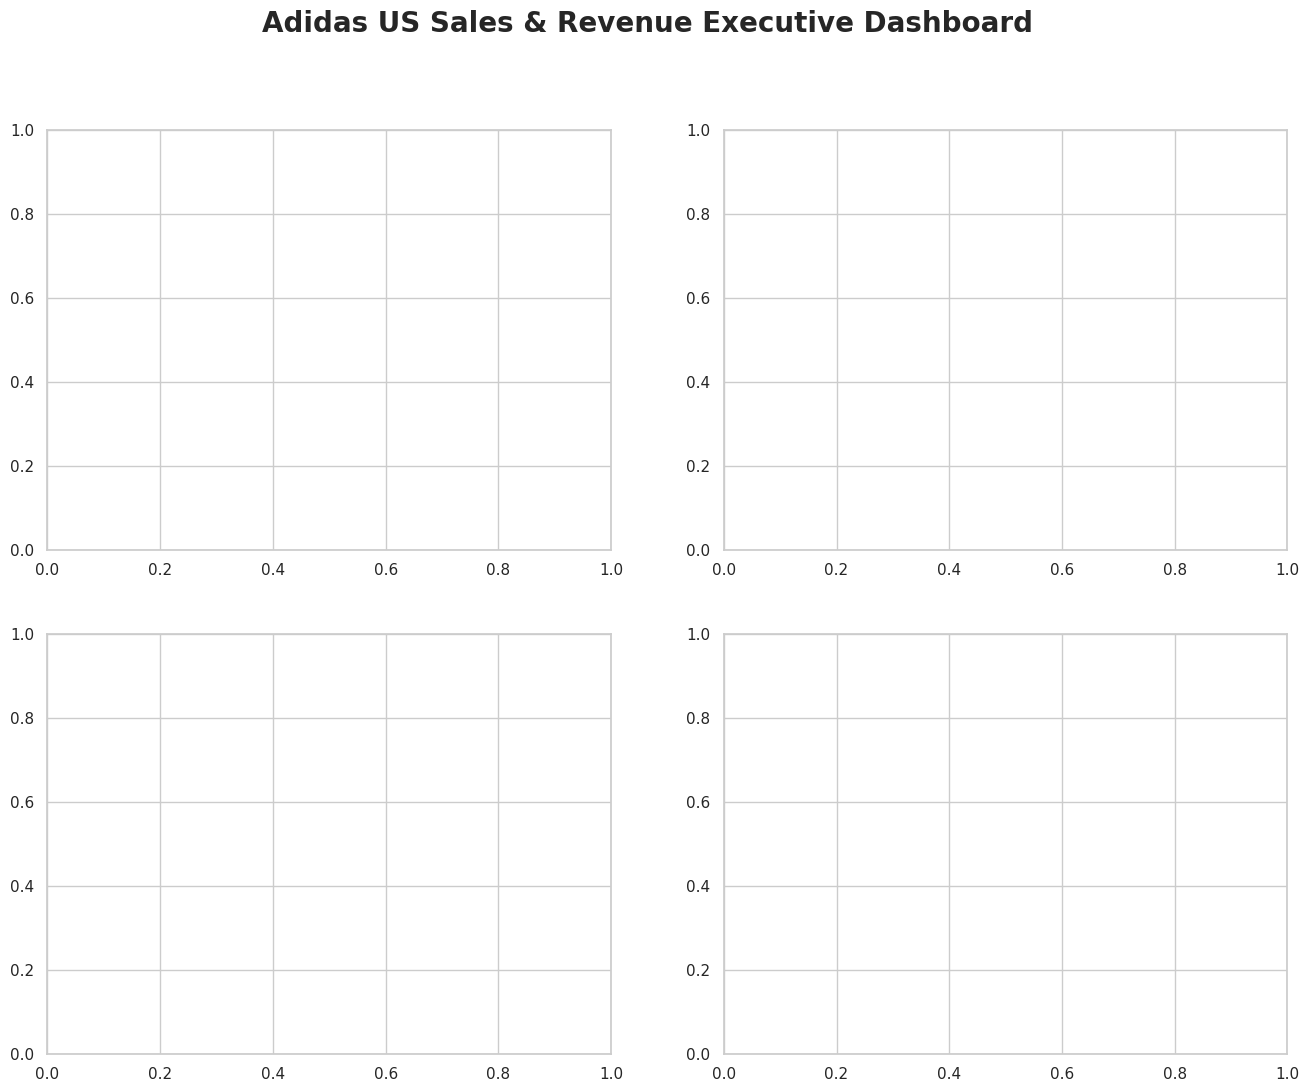

In [ ]:
# ============================================================
# TOP 10 STATES
# ============================================================

state_summary = df.groupby('State').agg(
    Total_Sales=('Total Sales', 'sum'),
    Operating_Profit=('Operating Profit', 'sum'),
    Units_Sold=('Units Sold', 'sum')
).reset_index().sort_values(
    by='Total_Sales',
    ascending=False
)


# ============================================================
# TOP 10 CITIES
# ============================================================

city_summary = df.groupby(['City', 'State']).agg(
    Total_Sales=('Total Sales', 'sum'),
    Operating_Profit=('Operating Profit', 'sum')
).reset_index().sort_values(
    by='Total_Sales',
    ascending=False
)


# ============================================================
# DISPLAY TOP 10 STATES AND CITIES
# ============================================================

print("Top 10 States by Sales:")
print(state_summary.head(10))


print("\nTop 10 Cities by Sales:")
print(city_summary.head(10))


# ============================================================
# YEARLY SALES
# ============================================================

# Make sure Invoice Date is in datetime format
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

yearly = df.groupby(
    df['Invoice Date'].dt.year
).agg(
    Total_Sales=('Total Sales', 'sum'),
    Operating_Profit=('Operating Profit', 'sum'),
    Units_Sold=('Units Sold', 'sum')
)

# Calculate profit margin
yearly['Profit_Margin_%'] = (
    yearly['Operating_Profit'] /
    yearly['Total_Sales']
) * 100

print("\nYearly Sales:")
print(yearly)


# ============================================================
# SET PLOT STYLE
# ============================================================

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})


# ============================================================
# DASHBOARD FIGURE 1: EXECUTIVE OVERVIEW
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

fig.suptitle(
    'Adidas US Sales & Revenue Executive Dashboard',
    fontsize=20,
    fontweight='bold',
    y=0.98
)

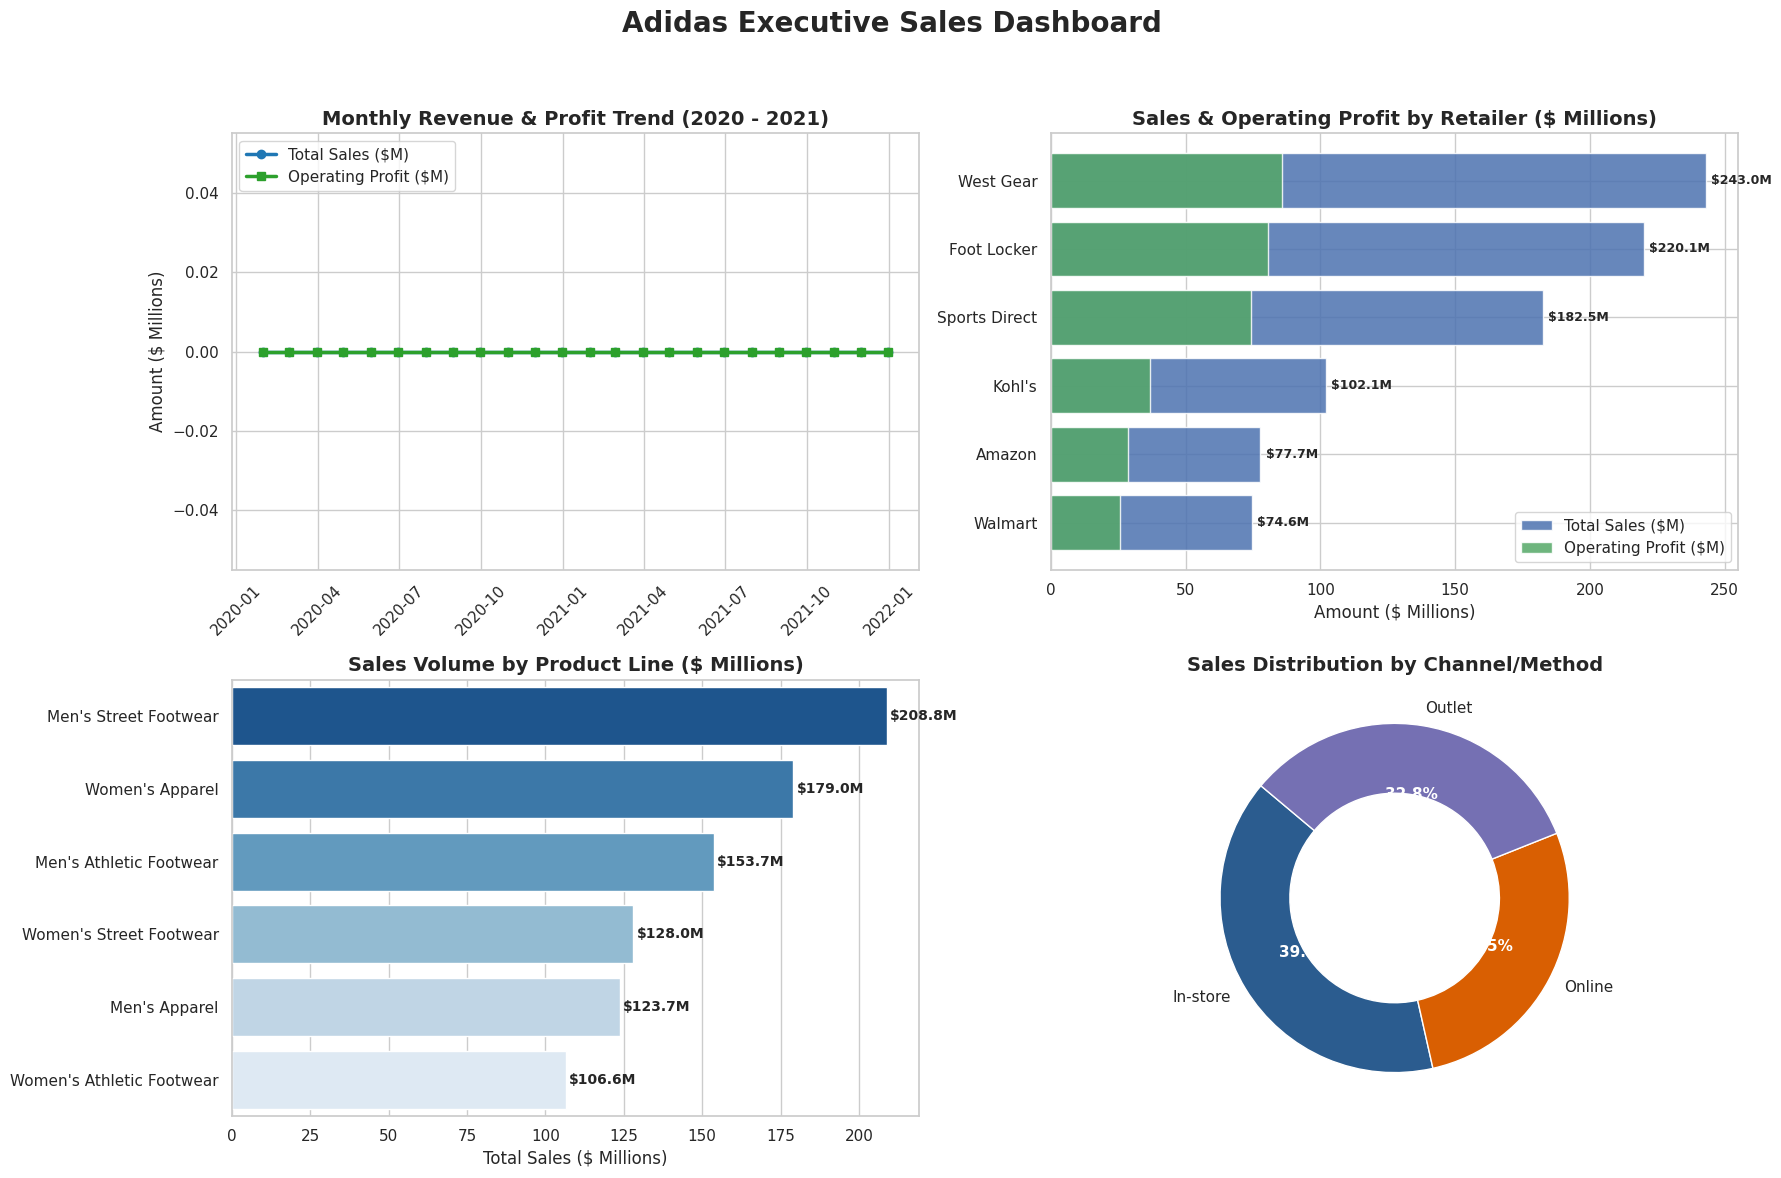

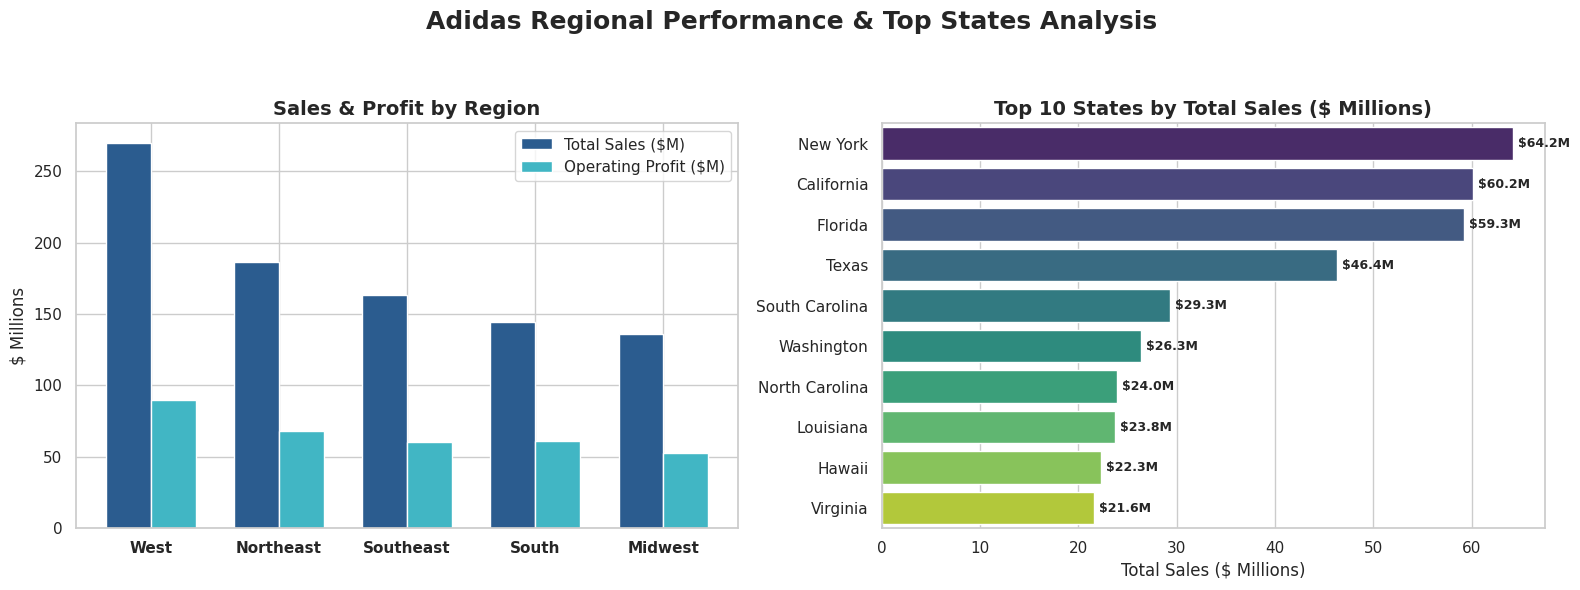

Charts created successfully!


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================================
# Dashboard Figure 1: Executive Dashboard
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Adidas Executive Sales Dashboard',
             fontsize=20, fontweight='bold')


# ------------------------------------------------------------
# Chart 1: Monthly Sales & Profit Trend
# ------------------------------------------------------------

ax1 = axes[0, 0]

ax1.plot(
    df_monthly['Invoice Date'],
    df_monthly['Total_Sales'] / 1e6,
    label='Total Sales ($M)',
    color='#1f77b4',
    linewidth=2.5,
    marker='o'
)

ax1.plot(
    df_monthly['Invoice Date'],
    df_monthly['Operating_Profit'] / 1e6,
    label='Operating Profit ($M)',
    color='#2ca02c',
    linewidth=2.5,
    marker='s'
)

ax1.set_title(
    'Monthly Revenue & Profit Trend (2020 - 2021)',
    fontsize=14,
    fontweight='bold'
)

ax1.set_ylabel('Amount ($ Millions)', fontsize=12)
ax1.legend(loc='upper left')
ax1.tick_params(axis='x', rotation=45)


# ------------------------------------------------------------
# Chart 2: Top Retailers by Sales & Profit
# ------------------------------------------------------------

ax2 = axes[0, 1]

retailer_df = df.groupby('Retailer').agg({
    'Total Sales': lambda x: x.sum() / 1e6,
    'Operating Profit': lambda x: x.sum() / 1e6
}).reset_index()

retailer_df = retailer_df.sort_values(
    by='Total Sales',
    ascending=True
)

bars = ax2.barh(
    retailer_df['Retailer'],
    retailer_df['Total Sales'],
    color='#4c72b0',
    alpha=0.85,
    label='Total Sales ($M)'
)

ax2.barh(
    retailer_df['Retailer'],
    retailer_df['Operating Profit'],
    color='#55a868',
    alpha=0.85,
    label='Operating Profit ($M)'
)

ax2.set_title(
    'Sales & Operating Profit by Retailer ($ Millions)',
    fontsize=14,
    fontweight='bold'
)

ax2.set_xlabel('Amount ($ Millions)', fontsize=12)
ax2.legend(loc='lower right')

for bar in bars:
    width = bar.get_width()

    ax2.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f'${width:.1f}M',
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )


# ------------------------------------------------------------
# Chart 3: Sales by Product
# ------------------------------------------------------------

ax3 = axes[1, 0]

prod_df = df.groupby('Product')['Total Sales'].sum().reset_index()

prod_df['Sales_M'] = prod_df['Total Sales'] / 1e6

prod_df = prod_df.sort_values(
    by='Sales_M',
    ascending=False
)

sns.barplot(
    data=prod_df,
    x='Sales_M',
    y='Product',
    hue='Product',
    palette='Blues_r',
    ax=ax3,
    legend=False
)

ax3.set_title(
    'Sales Volume by Product Line ($ Millions)',
    fontsize=14,
    fontweight='bold'
)

ax3.set_xlabel('Total Sales ($ Millions)', fontsize=12)
ax3.set_ylabel('')

for p in ax3.patches:

    ax3.annotate(
        f'${p.get_width():.1f}M',
        (
            p.get_width() + 1,
            p.get_y() + p.get_height() / 2
        ),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )


# ------------------------------------------------------------
# Chart 4: Sales Method Donut Chart
# ------------------------------------------------------------

ax4 = axes[1, 1]

method_df = df.groupby('Sales Method')['Total Sales'].sum()

colors = ['#2b5c8f', '#d95f02', '#7570b3']

wedges, texts, autotexts = ax4.pie(
    method_df,
    labels=method_df.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(
        width=0.4,
        edgecolor='w'
    )
)

plt.setp(
    autotexts,
    size=11,
    weight='bold',
    color='white'
)

ax4.set_title(
    'Sales Distribution by Channel/Method',
    fontsize=14,
    fontweight='bold'
)


# Save Dashboard 1

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    'adidas_executive_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()


# ============================================================
# Dashboard Figure 2: Regional & Geography Breakdown
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

fig.suptitle(
    'Adidas Regional Performance & Top States Analysis',
    fontsize=18,
    fontweight='bold'
)


# ------------------------------------------------------------
# Chart 5: Regional Sales & Profit
# ------------------------------------------------------------

reg_df = df.groupby('Region').agg(
    Total_Sales=(
        'Total Sales',
        lambda x: x.sum() / 1e6
    ),

    Operating_Profit=(
        'Operating Profit',
        lambda x: x.sum() / 1e6
    )
).reset_index()

reg_df = reg_df.sort_values(
    by='Total_Sales',
    ascending=False
)

ax_reg = axes[0]

x = np.arange(len(reg_df['Region']))
width = 0.35

ax_reg.bar(
    x - width / 2,
    reg_df['Total_Sales'],
    width,
    label='Total Sales ($M)',
    color='#2b5c8f'
)

ax_reg.bar(
    x + width / 2,
    reg_df['Operating_Profit'],
    width,
    label='Operating Profit ($M)',
    color='#41b6c4'
)

ax_reg.set_xticks(x)

ax_reg.set_xticklabels(
    reg_df['Region'],
    fontweight='bold'
)

ax_reg.set_ylabel(
    '$ Millions',
    fontsize=12
)

ax_reg.set_title(
    'Sales & Profit by Region',
    fontsize=14,
    fontweight='bold'
)

ax_reg.legend()


# ------------------------------------------------------------
# Chart 6: Top 10 States
# ------------------------------------------------------------

top_states = state_summary.head(10).copy()

top_states['Sales_M'] = (
    top_states['Total_Sales'] / 1e6
)

ax_state = axes[1]

sns.barplot(
    data=top_states,
    x='Sales_M',
    y='State',
    palette='viridis',
    hue='State',
    legend=False,
    ax=ax_state
)

ax_state.set_title(
    'Top 10 States by Total Sales ($ Millions)',
    fontsize=14,
    fontweight='bold'
)

ax_state.set_xlabel(
    'Total Sales ($ Millions)',
    fontsize=12
)

ax_state.set_ylabel('')

for p in ax_state.patches:

    ax_state.annotate(
        f'${p.get_width():.1f}M',
        (
            p.get_width() + 0.5,
            p.get_y() + p.get_height() / 2
        ),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )


# Save Dashboard 2

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    'adidas_regional_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Charts created successfully!")

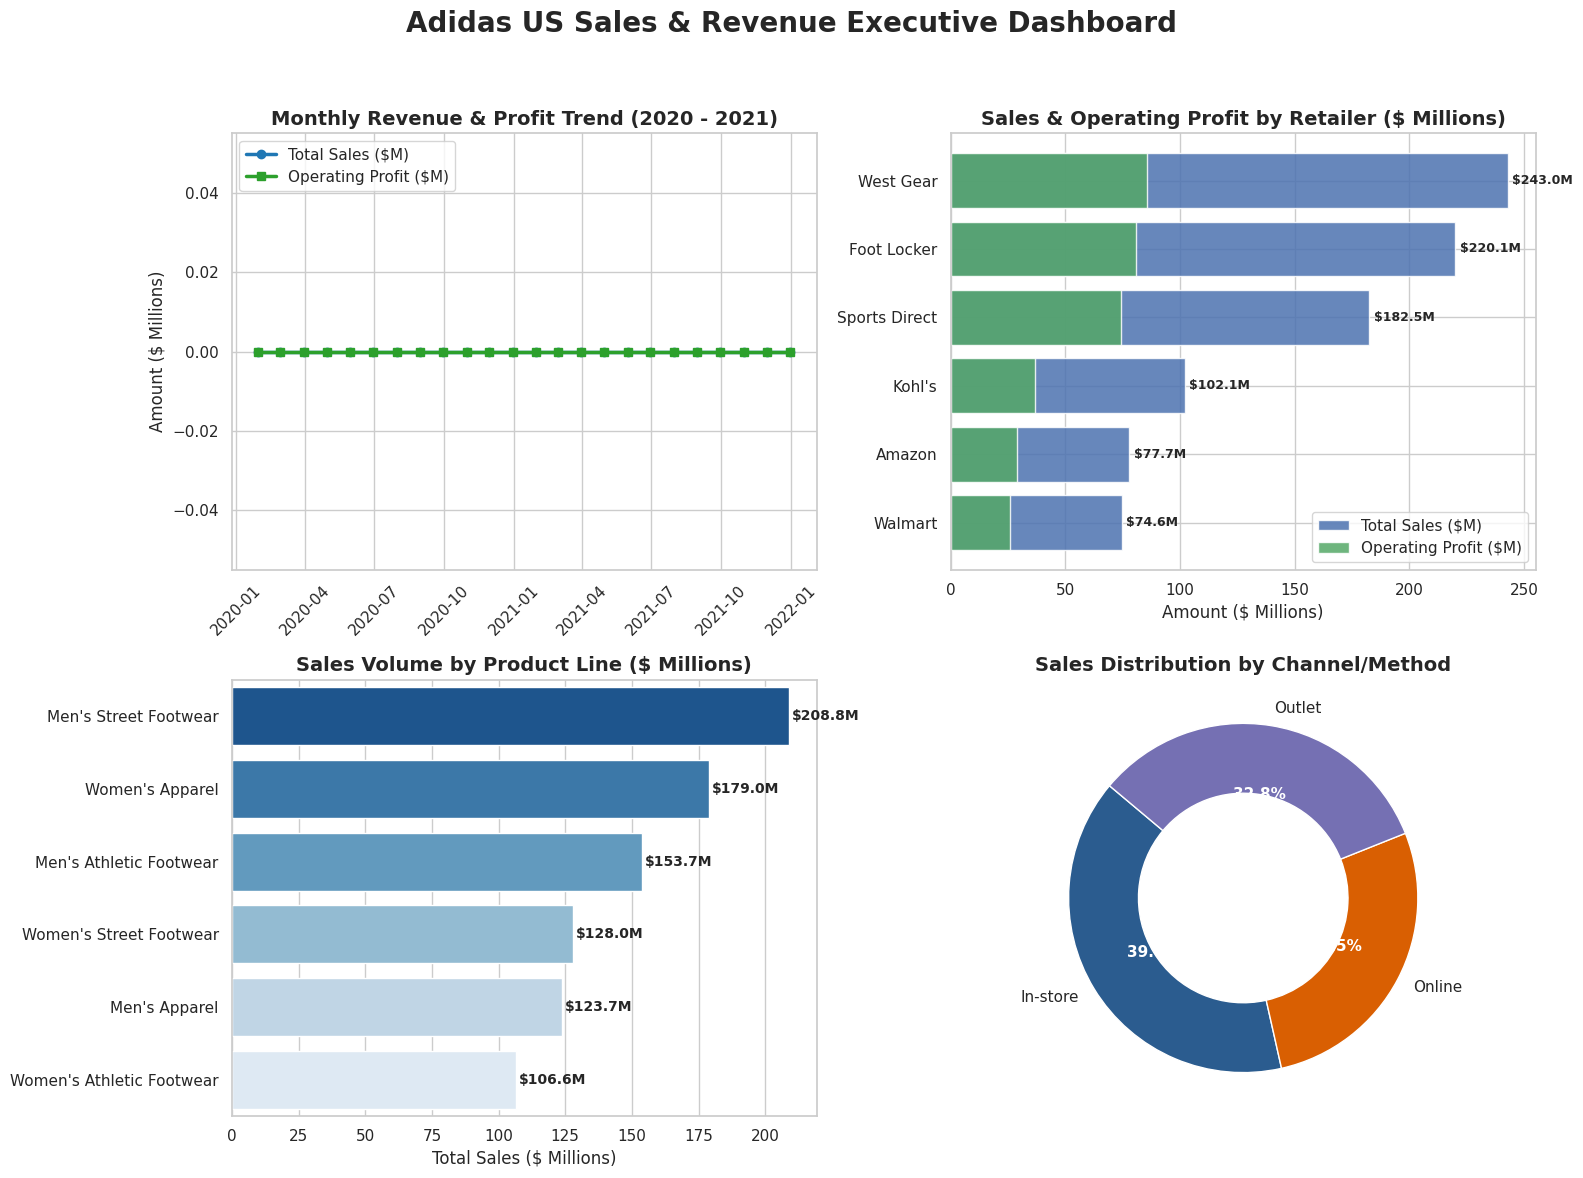

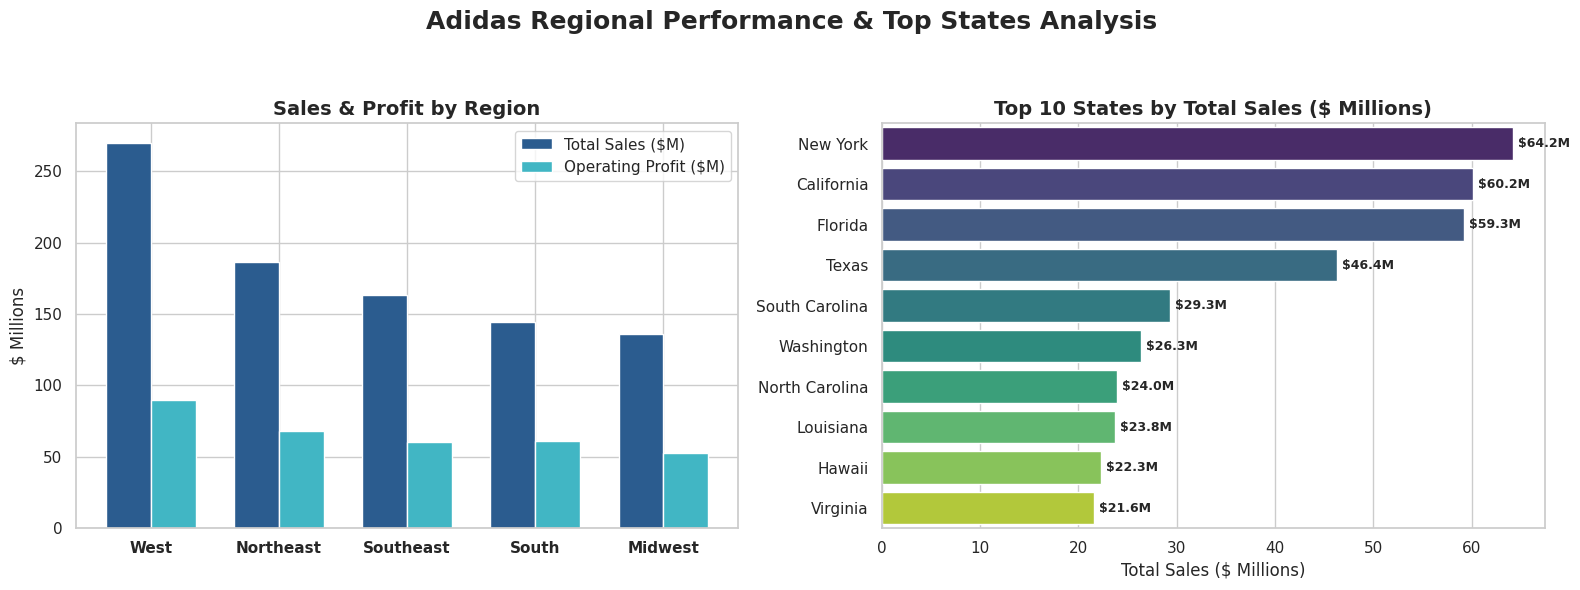

Both charts generated successfully!


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================================
# SET PLOT STYLE
# ============================================================

sns.set_theme(style="whitegrid")


# ============================================================
# DASHBOARD FIGURE 1: EXECUTIVE OVERVIEW
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle(
    'Adidas US Sales & Revenue Executive Dashboard',
    fontsize=20,
    fontweight='bold',
    y=0.98
)


# ============================================================
# CHART 1: MONTHLY SALES & PROFIT TREND
# ============================================================

ax1 = axes[0, 0]

ax1.plot(
    df_monthly['Invoice Date'],
    df_monthly['Total_Sales'] / 1e6,
    label='Total Sales ($M)',
    color='#1f77b4',
    linewidth=2.5,
    marker='o'
)

ax1.plot(
    df_monthly['Invoice Date'],
    df_monthly['Operating_Profit'] / 1e6,
    label='Operating Profit ($M)',
    color='#2ca02c',
    linewidth=2.5,
    marker='s'
)

ax1.set_title(
    'Monthly Revenue & Profit Trend (2020 - 2021)',
    fontsize=14,
    fontweight='bold'
)

ax1.set_ylabel(
    'Amount ($ Millions)',
    fontsize=12
)

ax1.legend(loc='upper left')

ax1.tick_params(
    axis='x',
    rotation=45
)


# ============================================================
# CHART 2: TOP RETAILERS BY SALES & PROFIT
# ============================================================

ax2 = axes[0, 1]

retailer_df = df.groupby('Retailer').agg({
    'Total Sales': lambda x: x.sum() / 1e6,
    'Operating Profit': lambda x: x.sum() / 1e6
}).reset_index()

retailer_df = retailer_df.sort_values(
    by='Total Sales',
    ascending=True
)

bars = ax2.barh(
    retailer_df['Retailer'],
    retailer_df['Total Sales'],
    color='#4c72b0',
    alpha=0.85,
    label='Total Sales ($M)'
)

ax2.barh(
    retailer_df['Retailer'],
    retailer_df['Operating Profit'],
    color='#55a868',
    alpha=0.85,
    label='Operating Profit ($M)'
)

ax2.set_title(
    'Sales & Operating Profit by Retailer ($ Millions)',
    fontsize=14,
    fontweight='bold'
)

ax2.set_xlabel(
    'Amount ($ Millions)',
    fontsize=12
)

ax2.legend(loc='lower right')


# Add sales labels
for bar in bars:
    width = bar.get_width()

    ax2.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        f'${width:.1f}M',
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )


# ============================================================
# CHART 3: SALES BY PRODUCT CATEGORY
# ============================================================

ax3 = axes[1, 0]

prod_df = df.groupby('Product')['Total Sales'].sum().reset_index()

prod_df['Sales_M'] = (
    prod_df['Total Sales'] / 1e6
)

prod_df = prod_df.sort_values(
    by='Sales_M',
    ascending=False
)

sns.barplot(
    data=prod_df,
    x='Sales_M',
    y='Product',
    hue='Product',
    palette='Blues_r',
    ax=ax3,
    legend=False
)

ax3.set_title(
    'Sales Volume by Product Line ($ Millions)',
    fontsize=14,
    fontweight='bold'
)

ax3.set_xlabel(
    'Total Sales ($ Millions)',
    fontsize=12
)

ax3.set_ylabel('')


# Add labels
for p in ax3.patches:

    ax3.annotate(
        f'${p.get_width():.1f}M',
        (
            p.get_width() + 1,
            p.get_y() + p.get_height() / 2
        ),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )


# ============================================================
# CHART 4: SALES METHOD DONUT CHART
# ============================================================

ax4 = axes[1, 1]

method_df = df.groupby(
    'Sales Method'
)['Total Sales'].sum()

colors = [
    '#2b5c8f',
    '#d95f02',
    '#7570b3'
]

wedges, texts, autotexts = ax4.pie(
    method_df,
    labels=method_df.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(
        width=0.4,
        edgecolor='w'
    )
)

plt.setp(
    autotexts,
    size=11,
    weight='bold',
    color='white'
)

ax4.set_title(
    'Sales Distribution by Channel/Method',
    fontsize=14,
    fontweight='bold'
)


# ============================================================
# SAVE EXECUTIVE DASHBOARD
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.savefig(
    'adidas_executive_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close()


# ============================================================
# DASHBOARD FIGURE 2: REGIONAL & GEOGRAPHY
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

fig.suptitle(
    'Adidas Regional Performance & Top States Analysis',
    fontsize=18,
    fontweight='bold'
)


# ============================================================
# CHART 5: REGIONAL SALES & PROFIT
# ============================================================

reg_df = df.groupby('Region').agg(
    Total_Sales=(
        'Total Sales',
        lambda x: x.sum() / 1e6
    ),

    Operating_Profit=(
        'Operating Profit',
        lambda x: x.sum() / 1e6
    )
).reset_index()

reg_df = reg_df.sort_values(
    by='Total_Sales',
    ascending=False
)

ax_reg = axes[0]

x = np.arange(
    len(reg_df['Region'])
)

width = 0.35

ax_reg.bar(
    x - width / 2,
    reg_df['Total_Sales'],
    width,
    label='Total Sales ($M)',
    color='#2b5c8f'
)

ax_reg.bar(
    x + width / 2,
    reg_df['Operating_Profit'],
    width,
    label='Operating Profit ($M)',
    color='#41b6c4'
)

ax_reg.set_xticks(x)

ax_reg.set_xticklabels(
    reg_df['Region'],
    fontweight='bold'
)

ax_reg.set_ylabel(
    '$ Millions',
    fontsize=12
)

ax_reg.set_title(
    'Sales & Profit by Region',
    fontsize=14,
    fontweight='bold'
)

ax_reg.legend()


# ============================================================
# CHART 6: TOP 10 STATES
# ============================================================

top_states = state_summary.head(10).copy()

top_states['Sales_M'] = (
    top_states['Total_Sales'] / 1e6
)

ax_state = axes[1]

sns.barplot(
    data=top_states,
    x='Sales_M',
    y='State',
    hue='State',
    palette='viridis',
    legend=False,
    ax=ax_state
)

ax_state.set_title(
    'Top 10 States by Total Sales ($ Millions)',
    fontsize=14,
    fontweight='bold'
)

ax_state.set_xlabel(
    'Total Sales ($ Millions)',
    fontsize=12
)

ax_state.set_ylabel('')


# Add labels
for p in ax_state.patches:

    ax_state.annotate(
        f'${p.get_width():.1f}M',
        (
            p.get_width() + 0.5,
            p.get_y() + p.get_height() / 2
        ),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )


# ============================================================
# SAVE REGIONAL DASHBOARD
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.savefig(
    'adidas_regional_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

plt.close()


print("Both charts generated successfully!")